In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics

In [4]:
data = pd.read_csv("CH.SC.U4CSE24156_EX-7.6_1(Decision tree).csv")

print(data)

    Age  Income Buy_House
0    22   22000        No
1    25   28000        No
2    28   32000        No
3    30   38000       Yes
4    32   45000       Yes
5    35   52000       Yes
6    38   58000       Yes
7    40   62000       Yes
8    42   68000       Yes
9    45   75000       Yes
10   27   30000        No
11   33   42000       Yes
12   36   65000       Yes
13   24   50000        No
14   31   70000       Yes
15   29   36000        No
16   34   48000       Yes
17   39   60000       Yes
18   41   72000       Yes
19   26   27000        No
20   37   55000       Yes
21   44   80000       Yes
22   23   24000        No
23   30   46000       Yes
24   35   56000       Yes
25   43   74000       Yes
26   28   34000        No
27   32   49000       Yes
28   40   66000       Yes
29   46   85000       Yes


In [6]:
data.head()

,Age,Income,Buy_House
0,22,22000,No
1,25,28000,No
2,28,32000,No
3,30,38000,Yes
4,32,45000,Yes


In [8]:
data.tail()

,Age,Income,Buy_House
25,43,74000,Yes
26,28,34000,No
27,32,49000,Yes
28,40,66000,Yes
29,46,85000,Yes


In [10]:
data.shape

(30, 3)

In [12]:
data.columns

Index(['Age', 'Income', 'Buy_House'], dtype='object')

In [14]:
data.isnull().sum()

Age          0
Income       0
Buy_House    0
dtype: int64

In [18]:
data.duplicated().sum()

0

In [22]:
data["Buy_House"] = data["Buy_House"].map({
    "No": 0,
    "Yes": 1
})

data.head()

,Age,Income,Buy_House
0,22,22000,0
1,25,28000,0
2,28,32000,0
3,30,38000,1
4,32,45000,1


In [24]:
X = data[["Age", "Income"]]

X.head()
y = data["Buy_House"]

y.head()
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 2)
y shape: (30,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24, 2)
X_test: (6, 2)
y_train: (24,)
y_test: (6,)


In [34]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=5
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred)


[1 1 1 1 1 0]


In [36]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result)

   Actual  Predicted
0       1          1
1       1          1
2       1          1
3       1          1
4       1          1
5       0          0


In [38]:
conf_mat = metrics.confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[1 0]
 [0 5]]


In [40]:
accuracy_score = metrics.accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", accuracy_score)

Accuracy Score: 1.0


In [42]:
print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [44]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

print(conf_mat)

Predicted  0  1
Actual         
0          1  0
1          0  5


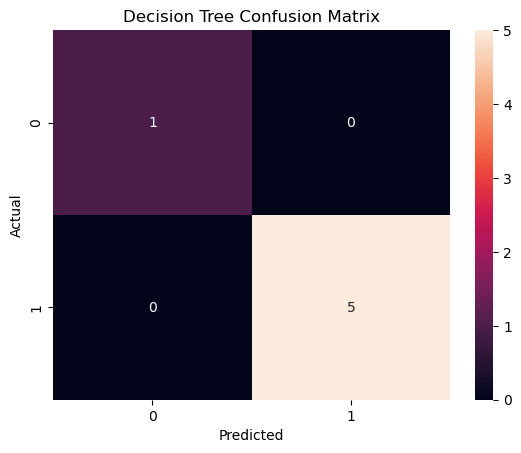

In [46]:
import seaborn as sns

sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()